# Day 3-01｜Detection IoU 與跨影格關聯


## 執行階段提醒

- 本 notebook 只示範「相鄰兩個 frame 之間，怎麼判斷哪些框可能是同一位球員」。
- 這裡先用最簡化的 IoU 關聯規則，目的是建立 tracking 直覺，不是完整重做 ByteTrack。


## 課程流程

1. 選擇相鄰兩個 frame，先跑一次 detector。
2. 只保留球員類別，觀察兩張圖中的 bbox。
3. 計算兩兩 bbox 的 IoU matrix。
4. 用簡化的 greedy 規則做跨影格配對。
5. 對照下一單元的 ByteTrack，理解它比純 IoU 多做了什麼。


In [1]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: /home/nckusoc/repos/basketball-hackathon-course
素材資料夾: /home/nckusoc/repos/basketball-hackathon-course/assets
工具模組: /home/nckusoc/repos/basketball-hackathon-course/src


## Step 1｜選擇影片、模型與相鄰 frame


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.yolo_utils import (
    PLAYER_CLASS_NAMES,
    detector_model_path,
    draw_detection_records,
    first_reference_video,
    read_video_frame,
    run_detector_on_image,
)

VIDEO_PATH = first_reference_video(COURSE_ROOT)
MODEL_PATH = detector_model_path(COURSE_ROOT)
FRAME_A = 15
FRAME_B = FRAME_A + 1
CONF = 0.25
IMGSZ = 960

print("video:", VIDEO_PATH)
print("model:", MODEL_PATH)
print("frame A:", FRAME_A)
print("frame B:", FRAME_B)


video: /home/nckusoc/repos/basketball-hackathon-course/assets/raw/reference_videos/boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
model: /home/nckusoc/repos/basketball-hackathon-course/assets/models/detectors/yolo26n_basketball_player_best.pt
frame A: 15
frame B: 16


## Step 2｜讀取兩個相鄰 frame，先看 detector 結果


In [3]:
frame_a = read_video_frame(VIDEO_PATH, FRAME_A)
frame_b = read_video_frame(VIDEO_PATH, FRAME_B)

dets_a, _ = run_detector_on_image(MODEL_PATH, frame_a, conf=CONF, imgsz=IMGSZ, frame_index=FRAME_A)
dets_b, _ = run_detector_on_image(MODEL_PATH, frame_b, conf=CONF, imgsz=IMGSZ, frame_index=FRAME_B)

players_a = [det for det in dets_a if det.class_name in PLAYER_CLASS_NAMES]
players_b = [det for det in dets_b if det.class_name in PLAYER_CLASS_NAMES]

print("frame A players:", len(players_a))
print("frame B players:", len(players_b))


frame A players: 10
frame B players: 10


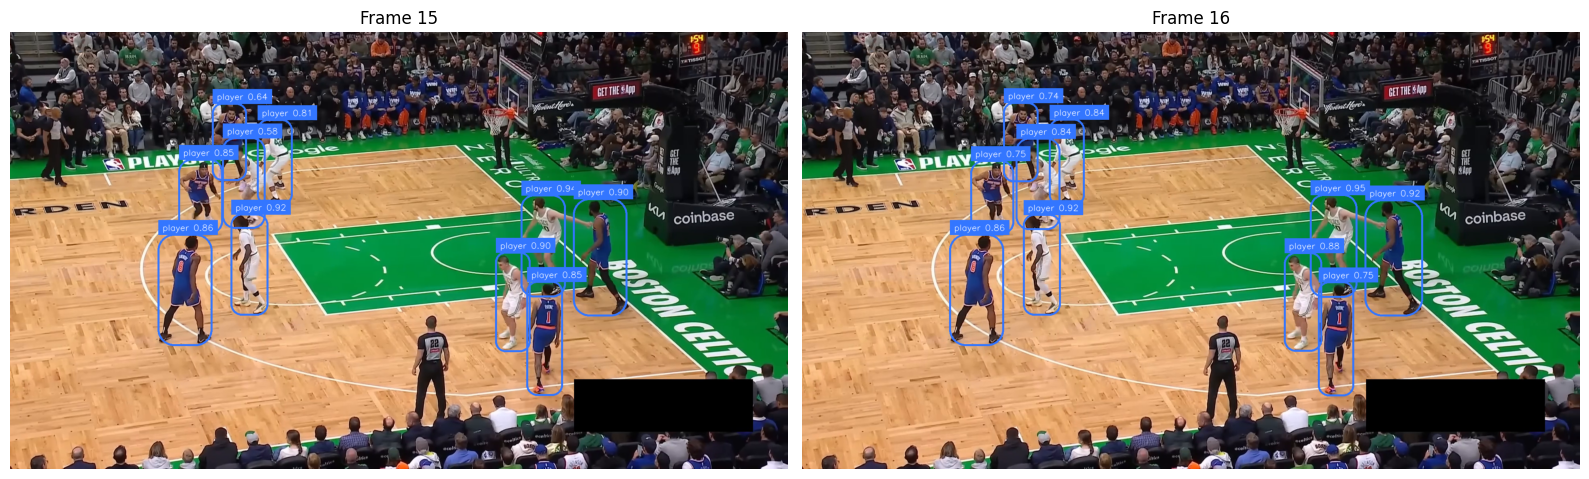

In [4]:
frame_a_vis = draw_detection_records(frame_a, players_a)
frame_b_vis = draw_detection_records(frame_b, players_b)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(frame_a_vis)
axes[0].set_title(f"Frame {FRAME_A}")
axes[0].axis("off")
axes[1].imshow(frame_b_vis)
axes[1].set_title(f"Frame {FRAME_B}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# label ID to player name mapping
# A0 A1 A2 | B0 B1 B2



## Step 3｜建立 IoU matrix

IoU（Intersection over Union）衡量兩個 bbox 的重疊程度：

$$
\mathrm{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

- 分子是交集面積：兩個框實際重疊多少。
- 分母是聯集面積：兩個框總共覆蓋多少。
- IoU 越大，表示這兩個 bbox 越可能是同一個目標在前後兩個 frame 的位置。


In [ ]:
def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)

    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union else 0.0

matrix = np.zeros((len(players_a), len(players_b)), dtype=float)
for i, det_a in enumerate(players_a):
    for j, det_b in enumerate(players_b):
        matrix[i, j] = iou(det_a.bbox_xyxy, det_b.bbox_xyxy)

matrix_df = pd.DataFrame(
    np.round(matrix, 3),
    index=[f"A{i}" for i in range(len(players_a))],
    columns=[f"B{j}" for j in range(len(players_b))],
)
matrix_df


,B0,B1,B2,B3,B4,B5,B6,B7,B8,B9
A0,0.922,0.000,0.000,0.043,0.000,0.000,0.000,0.000,0.063,0.000
A1,0.000,0.983,0.000,0.000,0.000,0.000,0.076,0.000,0.000,0.000
A2,0.000,0.000,0.916,0.000,0.000,0.000,0.000,0.000,0.000,0.000
A3,0.063,0.000,0.000,0.901,0.000,0.000,0.000,0.000,0.026,0.000
A4,0.000,0.000,0.000,0.000,0.983,0.000,0.000,0.000,0.000,0.000
A5,0.065,0.000,0.000,0.017,0.000,0.000,0.000,0.000,0.954,0.000
A6,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.957,0.000,0.038
A7,0.000,0.000,0.000,0.000,0.000,0.983,0.105,0.000,0.000,0.000
A8,0.000,0.000,0.000,0.000,0.000,0.000,0.159,0.030,0.000,0.943
A9,0.000,0.063,0.000,0.000,0.000,0.076,0.887,0.000,0.000,0.180


In [6]:
display(matrix_df.style.background_gradient(cmap="YlOrRd", axis=None))


,B0,B1,B2,B3,B4,B5,B6,B7,B8,B9
A0,0.922000,0.000000,0.000000,0.043000,0.000000,0.000000,0.000000,0.000000,0.063000,0.000000
A1,0.000000,0.983000,0.000000,0.000000,0.000000,0.000000,0.076000,0.000000,0.000000,0.000000
A2,0.000000,0.000000,0.916000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A3,0.063000,0.000000,0.000000,0.901000,0.000000,0.000000,0.000000,0.000000,0.026000,0.000000
A4,0.000000,0.000000,0.000000,0.000000,0.983000,0.000000,0.000000,0.000000,0.000000,0.000000
A5,0.065000,0.000000,0.000000,0.017000,0.000000,0.000000,0.000000,0.000000,0.954000,0.000000
A6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.957000,0.000000,0.038000
A7,0.000000,0.000000,0.000000,0.000000,0.000000,0.983000,0.105000,0.000000,0.000000,0.000000
A8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.159000,0.030000,0.000000,0.943000
A9,0.000000,0.063000,0.000000,0.000000,0.000000,0.076000,0.887000,0.000000,0.000000,0.180000


## Step 4｜先看每個 A 框最像哪個 B 框

這一步不急著直接配對，而是先看每一列的最大值。這樣學生會比較容易理解：

- `A0` 在下一個 frame 最像哪個框？
- 這個最大 IoU 有沒有高到值得相信？


In [7]:
best_match_rows = []
for i in range(matrix.shape[0]):
    if matrix.shape[1] == 0:
        break
    j = int(matrix[i].argmax())
    best_match_rows.append(
        {
            "frame_a_box": f"A{i}",
            "best_frame_b_box": f"B{j}",
            "best_iou": float(matrix[i, j]),
        }
    )

best_match_df = pd.DataFrame(best_match_rows)
best_match_df


,frame_a_box,best_frame_b_box,best_iou
0,A0,B0,0.922036
1,A1,B1,0.983012
2,A2,B2,0.916320
3,A3,B3,0.900793
4,A4,B4,0.983241
5,A5,B8,0.953778
6,A6,B7,0.956869
7,A7,B5,0.982806
8,A8,B9,0.942697
9,A9,B6,0.886958


## Step 5｜用簡化 greedy 規則做關聯

這裡採用一個容易講解的版本：

1. 對每個 `A_i` 找到 IoU 最大的 `B_j`。
2. 如果該 IoU 大於門檻值（這裡用 `0.30`），就視為候選配對。
3. 每個 `B_j` 只能被配對一次。

這不是 ByteTrack 的完整策略，但已經足夠建立「跨影格配對」的基本概念。


In [8]:
IOU_THRESHOLD = 0.30
assignments = []
used_b = set()

for i in range(matrix.shape[0]):
    if matrix.shape[1] == 0:
        break
    j = int(matrix[i].argmax())
    score = float(matrix[i, j])
    if score >= IOU_THRESHOLD and j not in used_b:
        used_b.add(j)
        assignments.append(
            {
                "frame_a_box": f"A{i}",
                "frame_b_box": f"B{j}",
                "iou": round(score, 3),
            }
        )

assignment_df = pd.DataFrame(assignments)
assignment_df


,frame_a_box,frame_b_box,iou
0,A0,B0,0.922
1,A1,B1,0.983
2,A2,B2,0.916
3,A3,B3,0.901
4,A4,B4,0.983
5,A5,B8,0.954
6,A6,B7,0.957
7,A7,B5,0.983
8,A8,B9,0.943
9,A9,B6,0.887


In [ ]:
# Merge the assignment results with the original detection records for frame A and frame B
# A0 A1 A2 | B0 B1 B2
# to 
# 1 2 3 4 5



ByteTrack 會同時考慮高低 confidence detections、既有 track state、丟失後再接回等情況，不只靠單一 pairwise IoU。下一單元會直接在影片上產生 `track_id`，讓你觀察 ID 如何跨 frame 延續。


## 本單元產出檔案

- 這個 notebook 主要產出是 IoU matrix 與 assignment 表格。
- 不另外寫出影片，因為重點是理解跨影格關聯的數學概念。
